In [24]:
from imitation.scripts.generate_ranked_trajectories import generate_policies_and_videos, generate_trajectories, record_trajectory_video 
import numpy as np

ENV_NAME = "CartPole-v1"
ITERATION_STEP = 1000
NUM_POLICIES = 10

video_entries, policy_entries = generate_policies_and_videos(NUM_POLICIES, ITERATION_STEP, ENV_NAME)
trajectory_entries = generate_trajectories(policy_entries[0:len(policy_entries)//2], ENV_NAME, no_trajectories=10)

for i in range(0, len(trajectory_entries)):
    print(trajectory_entries[i]["trajectory"].rews.shape) # why is reward capped at 500 ? 

print(len(trajectory_entries))


ppo_cartpole_1000 already exists.
ppo_cartpole_2000 already exists.
ppo_cartpole_3000 already exists.
ppo_cartpole_4000 already exists.
ppo_cartpole_5000 already exists.
ppo_cartpole_6000 already exists.
ppo_cartpole_7000 already exists.
ppo_cartpole_8000 already exists.
ppo_cartpole_9000 already exists.
ppo_cartpole_10000 already exists.
(62,)
(42,)
(53,)
(44,)
(42,)
(52,)
(45,)
(39,)
(49,)
(64,)
(115,)
(146,)
(144,)
(124,)
(151,)
(134,)
(125,)
(128,)
(116,)
(133,)
(206,)
(270,)
(157,)
(265,)
(253,)
(141,)
(184,)
(267,)
(213,)
(273,)
(500,)
(182,)
(288,)
(321,)
(216,)
(176,)
(500,)
(500,)
(167,)
(500,)
(500,)
(500,)
(500,)
(179,)
(211,)
(212,)
(204,)
(245,)
(210,)
(486,)
50


In [26]:
def make_fragments(traj, frag_len=25, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    T = len(traj.obs) - 1  # last obs has no action
    if T < frag_len: return []
    starts = rng.integers(0, T - frag_len + 1, size=max(1, T // frag_len))
    return [(traj.obs[s:s+frag_len], traj.rews) for s in starts]

def make_ranked_pairs(trajs, n_pairs=20000, frag_len=25, rng=None, tie_margin=0.0):
    rng = np.random.default_rng() if rng is None else rng
    # flatten all fragments
    frags = []
    for tr in trajs:
        trj = tr["trajectory"]
        frags += make_fragments(trj, frag_len, rng)
        print(len(frags))
    frags = [(o.astype(np.float32), r.astype(np.float32)) for o,r in frags]
    # sample pairs + label by true return
    pairs = []
    for _ in range(min(n_pairs, len(frags)**2)):
        i, j = rng.integers(0, len(frags), size=2)
        (o1, r1), (o2, r2) = frags[i], frags[j]
        g1, g2 = float(r1.sum()), float(r2.sum())
        if abs(g1-g2) <= tie_margin: continue
        y = 1.0 if g1 > g2 else 0.0
        pairs.append((o1, o2, y))
    return pairs

In [27]:
# Building ranked pairs as a learning dataset
pairs = []
for i, t1 in enumerate(trajectory_entries):
    for j, t2 in enumerate(trajectory_entries):
        if i >= j: continue
        if sum(t1["trajectory"].rews) == sum(t2["trajectory"].rews): continue 
        y = 1.0 if sum(t1["trajectory"].rews) > sum(t2["trajectory"].rews) else 0.0
        pairs.append((t1["trajectory"].obs, t2["trajectory"].obs, y))

print(len(pairs))

1203


In [28]:
pairs = []
pairs = make_ranked_pairs(trajectory_entries)
print(len(pairs))

2
3
5
6
7
9
10
11
12
14
18
23
28
32
38
43
48
53
57
62
70
80
86
96
106
111
118
128
136
146
166
173
184
196
204
211
231
251
257
277
297
317
337
344
352
360
368
377
385
404
17335


In [44]:

#TODO: add collatefn to add padding (or do it ealier)

from torch.utils.data import Dataset, DataLoader, random_split
import torch

def collate_pad(batch):
    # pad sequences to same T (left pad=False → right pad with zeros)
    o1s, o2s, ys = zip(*batch)
    T1 = max(x.shape[0] for x in o1s); T2 = max(x.shape[0] for x in o2s)
    def pad(stack, T):
        D = stack[0].shape[1]
        out = torch.zeros(len(stack), T, D)
        for i,x in enumerate(stack):
            out[i,:x.shape[0]] = x
        return out
    return pad(o1s, T1), pad(o2s, T2), torch.stack(ys)

class PrefPairsDS(Dataset):
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        o1, o2, y = self.pairs[i]               # (T, obs_dim), (T, obs_dim), scalar
        return torch.from_numpy(o1), torch.from_numpy(o2), torch.tensor(y, dtype=torch.float32)

pairs_dataset = PrefPairsDS(pairs)
val_fraction = 0.2
val_size = max(1, int(len(pairs_dataset) * val_fraction))
train_size = len(pairs_dataset) - val_size
if train_size <= 0:
    raise ValueError('Not enough preference pairs to create a training split.')
generator = torch.Generator().manual_seed(0)
train_dataset, val_dataset = random_split(pairs_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_pad)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_pad)


In [47]:
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym

obs_dim = gym.make(ENV_NAME).observation_space.shape[0]

class RewardMLP(nn.Module):
    def __init__(self, obs_dim, hid=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hid), nn.Tanh(),
            nn.Linear(hid, hid), nn.Tanh(),
            nn.Linear(hid, 1)
        )
    def forward(self, x):            # x: (B, D)
        return self.net(x).squeeze(-1)

reward_net = RewardMLP(obs_dim)
opt = torch.optim.Adam(reward_net.parameters(), lr=3e-4)
device = torch.device("cpu"); reward_net.to(device)

def pred_frag_return(obs_seq):       # (B, T, D) -> (B,)
    B,T,D = obs_seq.shape
    r = reward_net(obs_seq.reshape(B*T, D)).view(B,T).sum(dim=1)
    return r

def bt_loss(r1, r2, y):              # y in {0,1}
    return F.binary_cross_entropy_with_logits(r1 - r2, y)



In [48]:

import matplotlib.pyplot as plt

num_epochs = 300
train_losses, val_losses = [], []

def run_epoch(data_loader, train=True):
    reward_net.train(mode=train)
    total_loss, n_batches = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for o1, o2, y in data_loader:
            o1, o2, y = o1.to(device), o2.to(device), y.to(device)
            T = min(o1.shape[1], o2.shape[1])
            o1, o2 = o1[:, :T], o2[:, :T]
            r1, r2 = pred_frag_return(o1), pred_frag_return(o2)
            loss = bt_loss(r1, r2, y)
            if train:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(reward_net.parameters(), 5.0)
                opt.step()
            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(1, n_batches)

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch:02d}/{num_epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")


Epoch 01/300  train_loss=0.5752  val_loss=0.5340
Epoch 02/300  train_loss=0.5271  val_loss=0.5200
Epoch 03/300  train_loss=0.5119  val_loss=0.5170
Epoch 04/300  train_loss=0.5048  val_loss=0.4969
Epoch 05/300  train_loss=0.4926  val_loss=0.5042
Epoch 06/300  train_loss=0.4815  val_loss=0.4800
Epoch 07/300  train_loss=0.4747  val_loss=0.5003
Epoch 08/300  train_loss=0.4675  val_loss=0.4656
Epoch 09/300  train_loss=0.4614  val_loss=0.4584
Epoch 10/300  train_loss=0.4524  val_loss=0.4548
Epoch 11/300  train_loss=0.4514  val_loss=0.4579
Epoch 12/300  train_loss=0.4413  val_loss=0.4588
Epoch 13/300  train_loss=0.4324  val_loss=0.4382
Epoch 14/300  train_loss=0.4305  val_loss=0.4289
Epoch 15/300  train_loss=0.4245  val_loss=0.4307
Epoch 16/300  train_loss=0.4155  val_loss=0.4134
Epoch 17/300  train_loss=0.4105  val_loss=0.4088
Epoch 18/300  train_loss=0.4042  val_loss=0.4108
Epoch 19/300  train_loss=0.3990  val_loss=0.3974
Epoch 20/300  train_loss=0.3927  val_loss=0.3892
Epoch 21/300  train_

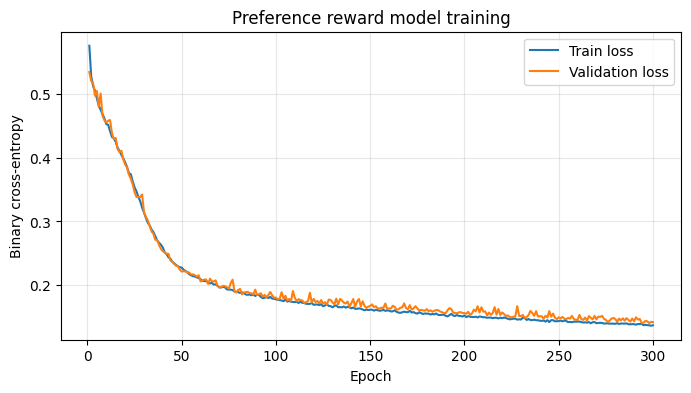

In [49]:

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy')
plt.title('Preference reward model training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# sanity check: does rewardnet successfully extrapolate ? 

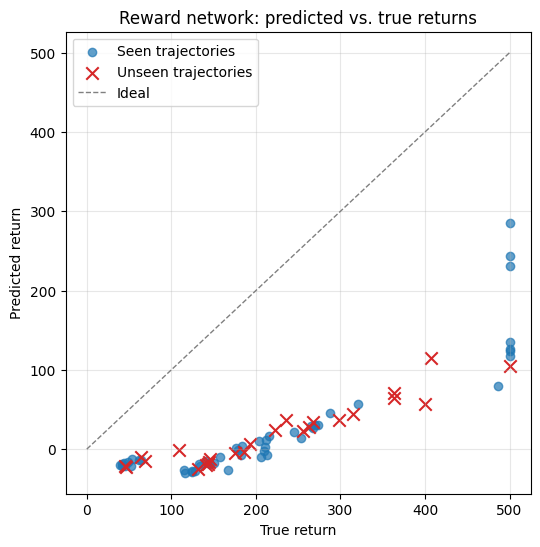

In [51]:

import torch
import matplotlib.pyplot as plt

# Compare predicted vs. true returns on seen and unseen trajectories

def evaluate_trajectory(traj):
    obs = torch.from_numpy(traj.obs.astype(np.float32)).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = pred_frag_return(obs).item()
    true = float(traj.rews.sum())
    return true, pred

seen_stats = [evaluate_trajectory(entry["trajectory"]) for entry in trajectory_entries]

# Generate a small batch of trajectories from policies not used for training pairs
unseen_policy_entries = policy_entries[:len(policy_entries)//2]
unseen_entries = generate_trajectories(unseen_policy_entries, ENV_NAME, no_trajectories=5)
unseen_stats = [evaluate_trajectory(entry["trajectory"]) for entry in unseen_entries]

plt.figure(figsize=(6, 6))
plt.scatter(*zip(*seen_stats), label='Seen trajectories', alpha=0.7)
if unseen_stats:
    plt.scatter(*zip(*unseen_stats), label='Unseen trajectories', color='tab:red', marker='x', s=80)
max_reward = max([s[0] for s in seen_stats + unseen_stats] + [s[1] for s in seen_stats + unseen_stats])
plt.plot([0, max_reward], [0, max_reward], '--', color='gray', linewidth=1, label='Ideal')
plt.xlabel('True return')
plt.ylabel('Predicted return')
plt.title('Reward network: predicted vs. true returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
